# Notebook for plotting MESH from radar observations

In [ ]:
# Import statements
from netCDF4 import Dataset
import wrf
from wrf import getvar, ALL_TIMES, latlon_coords, CoordPair, vertcross, to_np, interpline
import xarray as xr
import numpy as np
import cartopy.crs as crs
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib.cm as cm  
import matplotlib as mpl
import pandas as pd
from matplotlib.font_manager import FontProperties

In [ ]:
# Defining a WRF dataset for coordinates and urban outline
data_24_gr_4 = [Dataset('/g/data/li18/em3807/WRF_runs/wrfout_d02_2017-02-17_00:00:00')]

# Extracting SHI from radar data 
radar_2017_ter = xr.open_dataset('/g/data/rq0/level_2/71/SHI/71_20170218_shi.nc')
radar_2018_ter = xr.open_dataset('/g/data/rq0/level_2/71/SHI/71_20181220_shi.nc')
radar_2020_ter = xr.open_dataset('/g/data/rq0/level_2/71/SHI/71_20201217_shi.nc')
radar_2024_ter = xr.open_dataset('/g/data/rq0/level_2/71/SHI/71_20240213_shi.nc')

# Maximising SHI over the storm day
max_2017_ter = radar_2017_ter.shi.max(['time'])
max_2018_ter = radar_2018_ter.shi.max(['time'])
max_2020_ter = radar_2020_ter.shi.max(['time'])
max_2024_ter = radar_2024_ter.shi.max(['time'])

In [ ]:
# Defining functions
def calc_mesh(shi):
    a = 2.54
    b = 0.5
    mesh = a*shi**b 
    return mesh

def gr_coastline():
    grland = wrf.getvar(data_24_gr_4, 'LU_INDEX', timeidx=0, method='cat')
    wat = np.where(grland != 17, 0, grland)
    water = np.where(wat == 17, 1, wat)
    water[0:290, 0:130] = 0 
    water[26:290, 0:156] = 0
    water[26:33, 0:157] = 0 
    water[25:30, 0:156] = 0
    water[47:49, 0:167] = 0
    water[80:160, 0:175] = 0
    water[95:160, 0:177] = 0
    water[120:190, 0:182] = 0
    water[132:190, 0:186] = 0
    water[150:154, 0:203] = 0
    water[168:172, 0:214] = 0
    water[190:210, 0:215] = 0
    water[192:200, 0:218] = 0
    water[210:290, 0:225] = 0
    water[220:290, 0:233] = 0
    water[225:290, 0:236] = 0
    water[230:290, 0:237] = 0
    water[232:290, 0:241] = 0
    water[229:290, 0:237] = 0
    water[242:290, 0:245] = 0
    water[251:290, 0:250] = 0
    water[278:290, 0:266] = 0
    return water


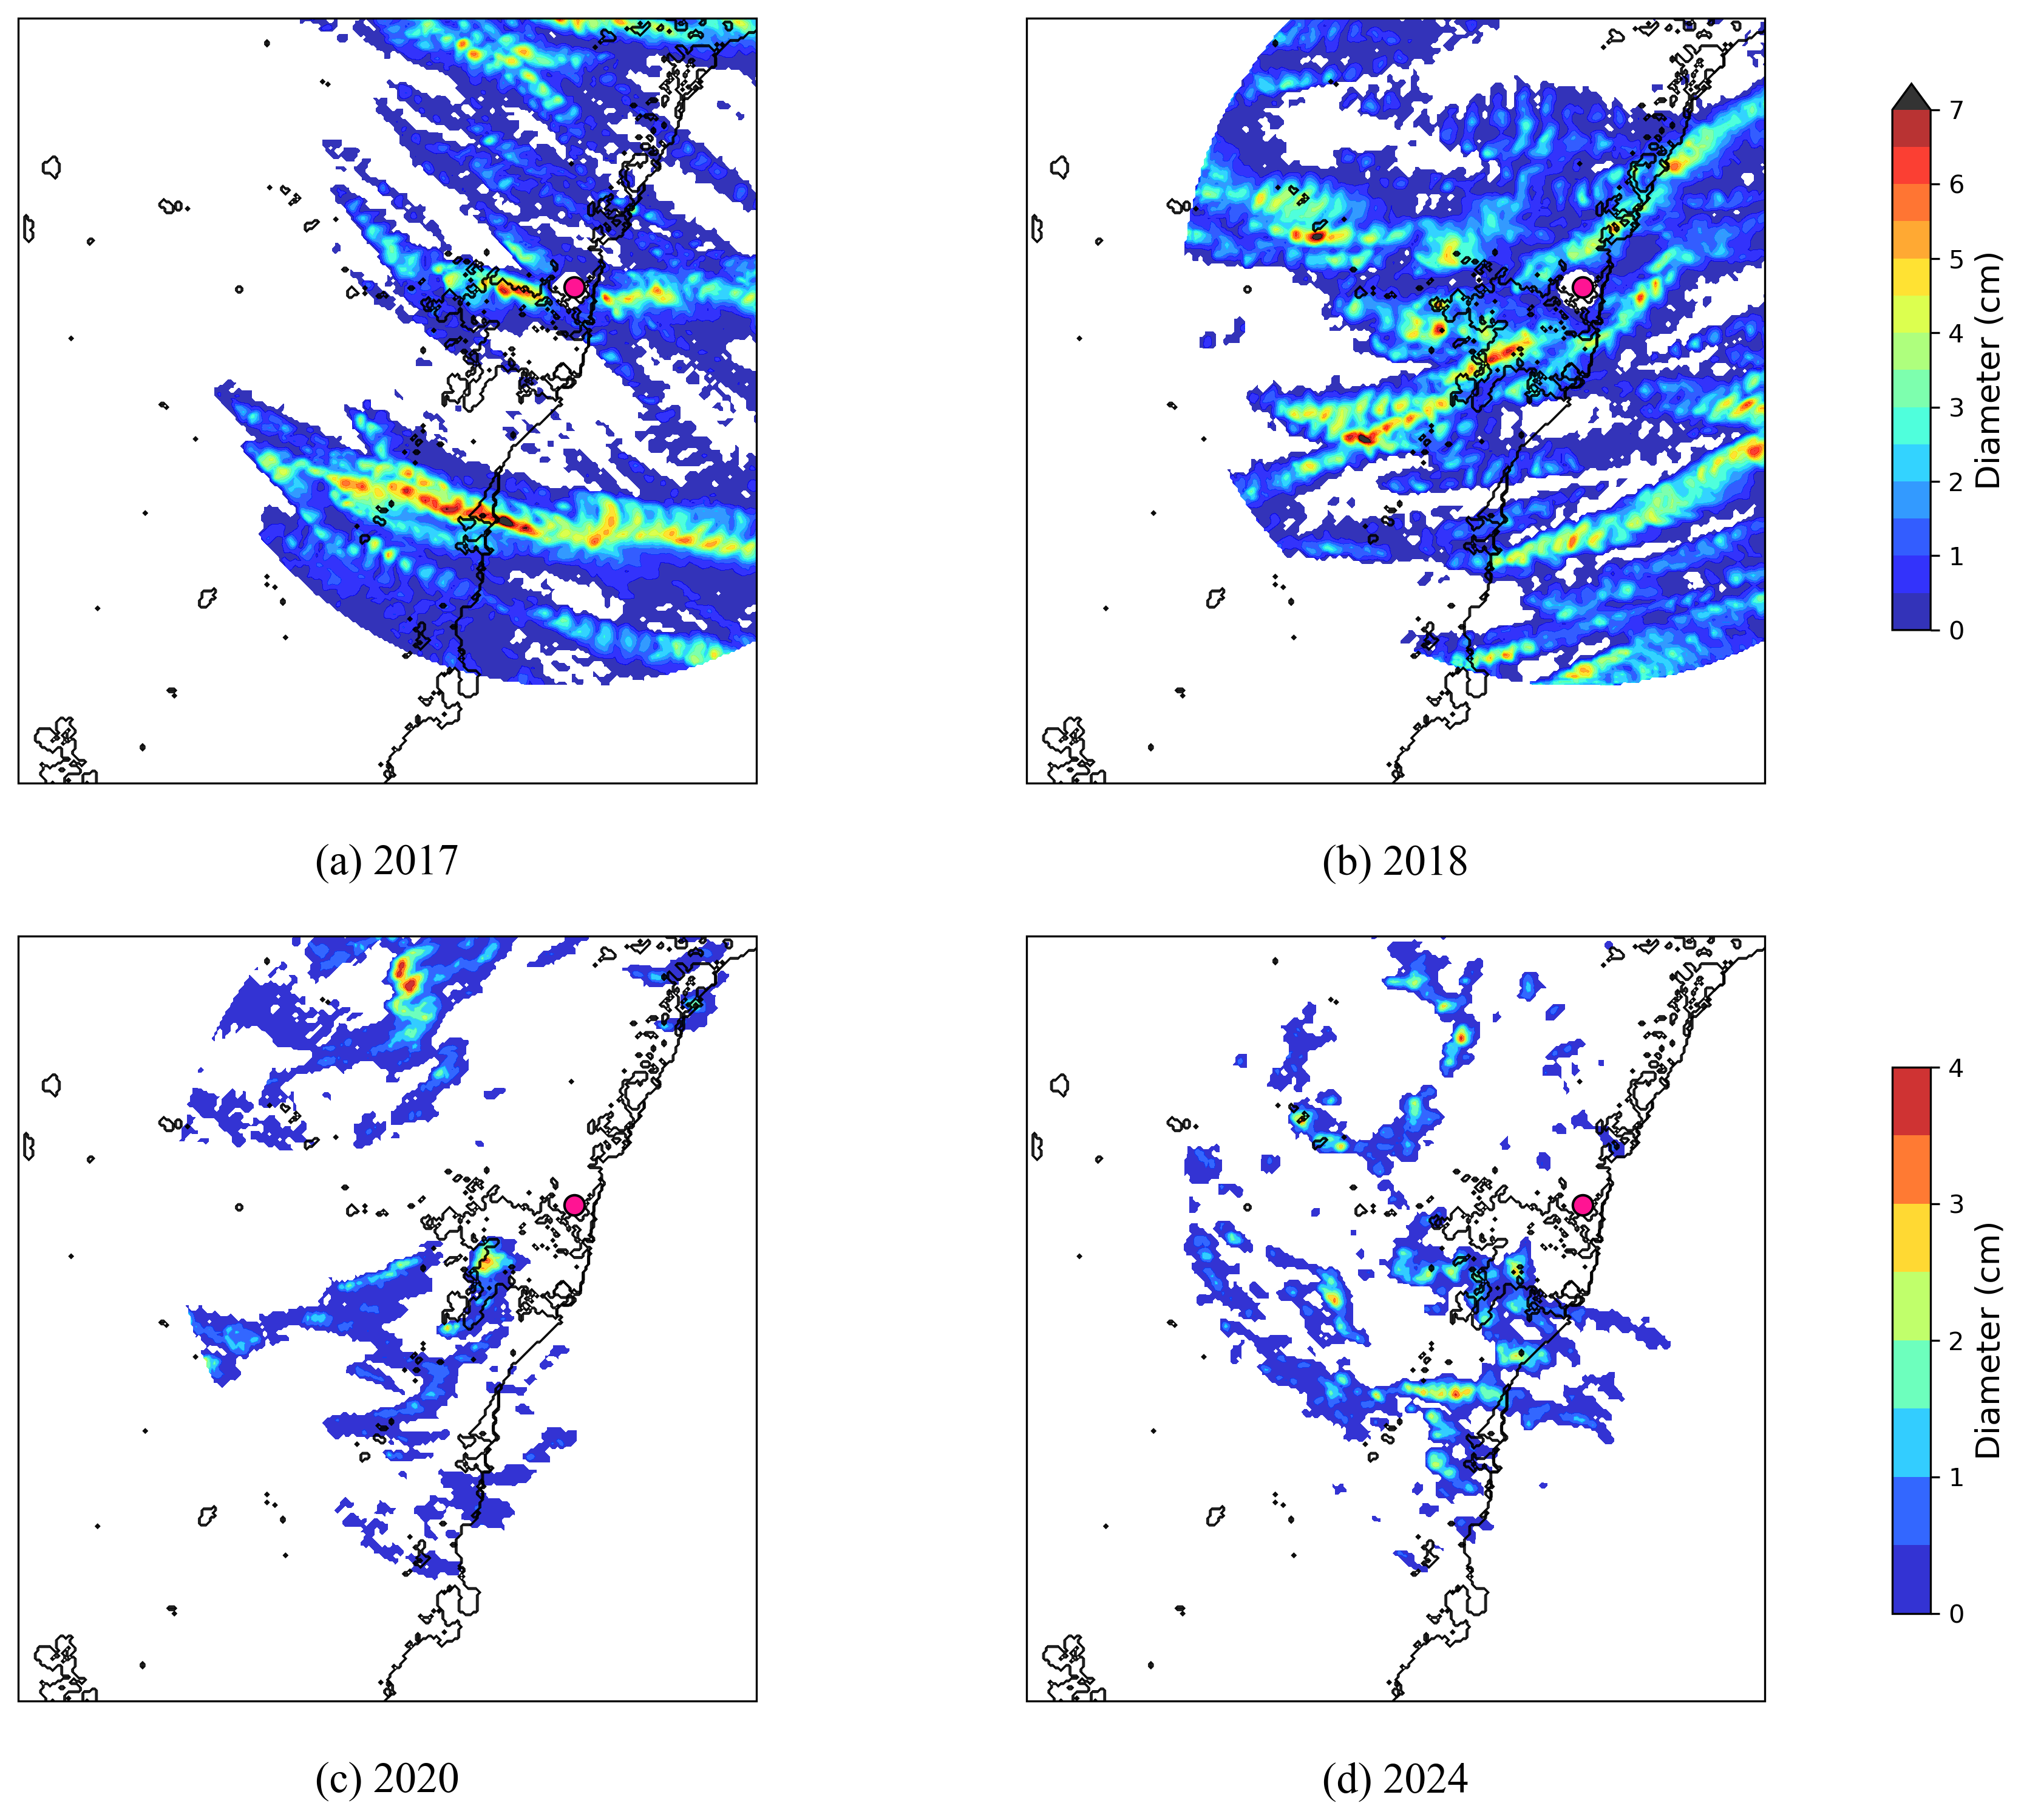

In [ ]:
# Calculating MESH
hail_2017 = calc_mesh(max_2017_ter)
hail_2018 = calc_mesh(max_2018_ter)
hail_2020 = calc_mesh(max_2020_ter)
hail_2024 = calc_mesh(max_2024_ter)
hail_list = [hail_2017, hail_2018, hail_2020, hail_2024]

# Defining the coordinates of the Terrey Hills radar
ter_lat = -33.6908
ter_lon = 151.2253

# For urban outline in WRF dataset
land = wrf.getvar(data_24_gr_4, 'LU_INDEX', timeidx=0, method='cat')
urb = np.where(land <= 49, 0, land) #set everything that isn't urban to zero
uniurb = np.where(urb >= 49, 1, urb) #make urban area uniform
years = ['2017','2018','2020','2024']
cmapb = (mpl.colors.ListedColormap(['black']))
cmapb.set_bad(alpha=0)
bounds = [0,1]
norm = mpl.colors.BoundaryNorm(bounds, cmapb.N)
font = FontProperties(family='Times New Roman')

t_lats = radar_2017_ter['latitude']
t_lons = radar_2017_ter['longitude']

# Defining the axes
lats2, lons2 = wrf.latlon_coords(land)
cart_proj = wrf.get_cartopy(land)
xy = cart_proj.transform_point(ter_lon, ter_lat, crs.PlateCarree())

fig, axd = plt.subplot_mosaic([['2017', '2018'], 
                               ['2020', '2024']], 
                              subplot_kw={'projection': cart_proj},
                              figsize=(14, 12), dpi=300)

# Setting levels for the contour plot
levels = np.linspace(0, 7, 15) 
levels2 = np.linspace(0, 4, 9) 
sub_labels = ['a', 'b', 'c', 'd']
years = ['2017', '2018', '2020', '2024']

cmap = plt.get_cmap('jet').copy()
cmap.set_extremes(over='black')

# Plotting MESH
for y_idx, year in enumerate(years):
    ax = axd[year]
    current_hail = hail_list[y_idx] / 10
    
    if year in ['2017', '2018']:
        mesh_fill = ax.contourf(wrf.to_np(t_lons), wrf.to_np(t_lats), wrf.to_np(current_hail), 
                                transform=crs.PlateCarree(), cmap=cmap, levels=levels, 
                                extend='max', alpha=0.8)
        if year == '2017': mesh_ter1 = mesh_fill # Reference for cbar1
    else:
        mesh_fill = ax.contourf(wrf.to_np(t_lons), wrf.to_np(t_lats), wrf.to_np(current_hail), 
                                transform=crs.PlateCarree(), cmap=cmap, levels=levels2, 
                                alpha=0.8)
        if year == '2020': mesh_ter2 = mesh_fill # Reference for cbar2

    ax.contour(wrf.to_np(lons2), wrf.to_np(lats2), wrf.to_np(uniurb), 
               transform=crs.PlateCarree(), cmap=cmapb, linewidths=0.2)
    ax.contour(wrf.to_np(lons2), wrf.to_np(lats2), wrf.to_np(gr_coastline()), 
               transform=crs.PlateCarree(), cmap=cmapb, linewidths=0.2) 
    
    ax.plot(xy[0], xy[1], marker='o', markersize=8, markerfacecolor='deeppink', 
            markeredgecolor='black', markeredgewidth=1)
    ax.set_xlim(wrf.cartopy_xlim(land))
    ax.set_ylim(wrf.cartopy_ylim(land))

    full_label = f"({sub_labels[y_idx]}) {year}"
    ax.text(0.5, -0.08, full_label, transform=ax.transAxes, 
            fontsize=17, fontproperties=font, va='top', ha='center')

fig.subplots_adjust(right=0.85, hspace=0.2) 
cbar_ax1 = fig.add_axes([0.88, 0.6, 0.015, 0.25]) 
cbar_ax2 = fig.add_axes([0.88, 0.15, 0.015, 0.25]) 

cbar = fig.colorbar(mesh_ter1, cax=cbar_ax1, ticks=np.linspace(0, 7, 8), extend='max')
cbar2 = fig.colorbar(mesh_ter2, cax=cbar_ax2, ticks=np.linspace(0, 4, 5))
cbar.set_label("Diameter (cm)", fontsize = 13)
cbar2.set_label("Diameter (cm)", fontsize = 13)

plt.show()